In [1]:
# Librerias y configuraciones iniciales

import os
import subprocess

# Intenta cargar variables de entorno desde ~/.bashrc usando bash
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    # Recorre cada línea de salida y agrega las variables al entorno de Python
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    # Si ocurre algún error (timeout, archivo inexistente, etc.), lo ignora
    pass

# Configura la variable PDKPATH si existen PDK_ROOT y PDK en el entorno
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))


# --- Librerías para manejo de layouts y visualización ---
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirige salidas a un widget oculto (útil en notebooks)
hide = widgets.Output()


def display_gds(gds_file, path, scale=3):
    """
    Lee un archivo GDS, lo convierte a SVG, escala la imagen y la muestra inline.
    """
    # Obtiene la celda top-level del GDS
    top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
    top_level_cell.write_svg(os.path.join(path, 'out.svg'))
    
    # Escala la imagen para mejorar la visualización
    fig = sg.fromfile(os.path.join(path, 'out.svg'))
    fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
    fig.save(os.path.join(path, 'out.svg'))

    # Muestra el SVG en el notebook
    IPython.display.display(IPython.display.SVG(os.path.join(path, 'out.svg')))
    os.remove(os.path.join(path, 'out.gds'))  # Limpieza del archivo temporal


def display_component(component, path, scale=3):
    """
    Guarda un componente en GDS y lo muestra usando display_gds.
    """
    with hide:
        component.write_gds(os.path.join(path, 'out.gds'))
    display_gds(os.path.join(path, 'out.gds'), path, scale)


# --- Importación de librerías específicas para layout y PDK ---
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array, mimcap
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter, print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# --- Configuración base para dispositivos NMOS y PMOS ---
neurona_config = {
    "pdk": gf180,  # Define el PDK a usar
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation() + 1,  # Espaciado mínimo entre metales
        "routing_metal": "met2",  # Capa metálica principal para ruteo
        "dummy_devices": False,   # No usar dispositivos dummy
        "tie_layers": ("met2", "met1"),  # Capas para conexiones de substrato
        "sd_rmult": 1,  # Multiplicador de source/drain
    },
}

# Parámetros para NMOS
nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": False
}

# Parámetros para PMOS
pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": False
}


# --- Creación del componente principal ---
pdk = gf180
neurona_comp = Component(name="neurona_lvs")  # Componente base para la neurona
neurona_comp.name = "neurona_lvs"

# Extrae reglas de layout desde la configuración
rules = neurona_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]



In [ ]:
help(mimcap)

Help on function mimcap in module glayout.primitives.mimcap:

mimcap(pdk: glayout.pdk.mappedpdk.MappedPDK, size: tuple[float, float] = (5.0, 5.0), option: str = 'B', with_extension: bool = True, extension_direction: str = 'S', extension_width: float = 0.0, extension_length: float = 0.0) -> gdsfactory.component.Component
    create a MIM capacitor according to GF180MCU Option A or Option B
    
    MIM Option A structure (Metal3-Metal2 stack):
    - FuseTop layer defines the top plate of MIM capacitor
    - Metal3 forms the actual top plate 
    - CAP_MK defines the dielectric layer
    - Metal2 forms the bottom plate
    - For 3 metal layer processes
    
    MIM Option B structure (Metal5-Metal4 stack):
    - FuseTop layer defines the top plate area
    - Metal5 (top metal) forms the actual top plate 
    - CAP_MK defines the dielectric
    - Metal4 (bottom metal) forms the bottom plate
    - MIM_L_MK marks the capacitor's length dimension
    - For 4+ metal layer processes
    
    a

In [3]:
# Create transistor primitives based on .spice parameters
# M1, M3, M7: PMOS W=0.22u, L=0.28u, nf=1
m1 = pmos(
    pdk,
    width=0.5,                   # Ancho del canal (ajustado respecto al valor SPICE)
    length=0.28,            # Longitud efectiva (escalada por factor 2.27)
    with_dummy=(False, False),   # No se colocan transistores dummy
    with_substrate_tap=False,    # Sin conexión explícita al substrato
    tie_layers=tie_layers,       # Capas metálicas usadas para conexiones de substrato
    sd_rmult=sd_rmult,           # Multiplicador de ancho en source/drain
    **pmos_kwargs                # Parámetros adicionales definidos previamente
)

m3 = pmos(
    pdk,
    width=0.5,                   # Ancho del canal (ajustado respecto al valor SPICE)
    length=0.28,            # Longitud efectiva (escalada por factor 2.27)
    with_dummy=(False, False),   # No se colocan transistores dummy
    with_substrate_tap=False,    # Sin conexión explícita al substrato
    tie_layers=tie_layers,       # Capas metálicas usadas para conexiones de substrato
    sd_rmult=sd_rmult,           # Multiplicador de ancho en source/drain
    **pmos_kwargs                # Parámetros adicionales definidos previamente
)

m7 = pmos(
    pdk,
    width=0.5,                   # Ancho del canal (ajustado respecto al valor SPICE)
    length=0.28,            # Longitud efectiva (escalada por factor 2.27)
    with_dummy=(False, False),   # No se colocan transistores dummy
    with_substrate_tap=False,    # Sin conexión explícita al substrato
    tie_layers=tie_layers,       # Capas metálicas usadas para conexiones de substrato
    sd_rmult=sd_rmult,           # Multiplicador de ancho en source/drain
    **pmos_kwargs                # Parámetros adicionales definidos previamente
)


# M2, M4, M8: NMOS W=0.22u, L=0.28u, nf=1
m2 = nmos(
    pdk,
    width=0.5,
    length=0.28,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **nmos_kwargs
)

m4 = nmos(
    pdk,
    width=0.5,
    length=0.28,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **nmos_kwargs
)

m8 = nmos(
    pdk,
    width=0.5,
    length=0.28,
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **nmos_kwargs
)

# M5: Reset NMOS W=1.25u, L=50u, nf=1 (Long channel device)
m5_reset = nmos(
    pdk,
    width=2.3,                  # Transistor más ancho para reset
    length=50.0,                 # Canal largo (dispositivo de alta resistencia)
    with_dummy=(False, False),
    with_substrate_tap=False,
    tie_layers=tie_layers,
    sd_rmult=sd_rmult,
    **nmos_kwargs
)

# # XC2: MIM Capacitor (3 parallel caps with 5u x 5u geometry)
# cap_mim = mimcap_array(
#     pdk,
#     size=(15.0, 5.0),             # Cada capacitor mide 5x5 micras
#     columns=1,                   # Tres capacitores en paralelo (columna)
#     rows=1                       # Una fila
# )

cap_mim = mimcap(
    pdk,
    size=(15.0, 5.0),             # Cada capacitor mide 5x5 micras
    option="B"
)

# Renombrar instancias para identificación clara en LVS/Netlist
m1.name = "m1"
m3.name = "m3"
m7.name = "m7"
m2.name = "m2"
m4.name = "m4"
m8.name = "m8"
m5_reset.name = "m5"
cap_mim.name = "cap"

# ==============================================================================
# PLACEMENT & INSTANTIATION
# ==============================================================================

# Row 1: PMOS Transistors (M1, M3, M7)
m1_ref = neurona_comp << m1    # Instancia M1 en el componente neurona
m3_ref = neurona_comp << m3    # Instancia M3
m7_ref = neurona_comp << m7    # Instancia M7

# Row 2: Standard NMOS Transistors (M2, M4, M8) placed directly below PMOS
m2_ref = neurona_comp << m2   # Instancia M2
m4_ref = neurona_comp << m4    # Instancia M4
m8_ref = neurona_comp << m8    # Instancia M8

# Placement: Reset NMOS (M5) - Long channel, placed below M2/M4
m5_ref = neurona_comp << m5_reset

# Placement: MIM Capacitor Array (XC2) - Placed adjacent to the inverter core
cap_ref = neurona_comp << cap_mim



# Ensure grid snap compliance (alinear a la grilla de diseño)
# neurona_comp = component_snap_to_grid(neurona_comp)

# Display rendered placement component (visualización en notebook)
# display_component(stdp_comp, "./")


2026-08-25 04:23:13.302 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [4]:
# Funcion para visualizar el layout y realizar DRC
def view_and_check_lvs():
    """
    Función para visualizar el layout de la neurona LVS.
    Muestra el componente y realiza un DRC.
    """
    neurona_comp.show()
    display_component(neurona_comp, scale=2, path=".")
    drc_result = gf180.drc_magic(neurona_comp, neurona_comp.name)

#    # Revisar si hay errores
#    if drc_result.get("errors"):   # si la lista no está vacía
#        print(f"⚠ DRC encontró {len(drc_result['errors'])} violaciones")
#    else:
#        print("✔ DRC limpio: No errors found")
        
    return 

In [5]:
# Calcular coordenadas base para filas
bottom_row = evaluate_bbox(m2_ref)[1]/2
# → Altura de la fila inferior (NMOS), usando la mitad de la dimensión Y de M2

middle_row = bottom_row + evaluate_bbox(m5_ref)[1]
# → Fila intermedia: se coloca justo encima de la fila inferior,
#   sumando la altura del transistor de reset (M5)

top_row = middle_row + evaluate_bbox(m1_ref)[1] + 2
# → Fila superior: encima de la fila intermedia,
#   sumando la altura de un PMOS (M1) y un margen extra de 2 unidades

#-------------------------------------------------------------------------------

spacing_x = 1  # µm, ajusta según el reporte DRC

# --- Colocación de PMOS en la fila superior ---
m1_ref.move((0 + evaluate_bbox(m1_ref)[0]/2, top_row))
# → M1 se coloca en el origen X, centrado en su ancho, y en la fila superior

m3_ref.move((m1_ref.xmax + evaluate_bbox(m3_ref)[0]/2 + spacing_x, top_row))
# → M3 se coloca a la derecha de M1, usando xmax de M1 como referencia

m7_ref.move((m3_ref.xmax + evaluate_bbox(m7_ref)[0]/2 + spacing_x, top_row))
# → M7 se coloca a la derecha de M3

# --- Colocación de NMOS en la fila inferior ---
m2_ref.move((0 + evaluate_bbox(m2_ref)[0]/2, bottom_row))
# → M2 en el origen X, centrado, en la fila inferior

m4_ref.move((m2_ref.xmax + evaluate_bbox(m4_ref)[0]/2 + spacing_x, bottom_row))
# → M4 a la derecha de M2

m8_ref.move((m4_ref.xmax + evaluate_bbox(m8_ref)[0]/2 + spacing_x, bottom_row))
# → M8 a la derecha de M4

# --- Colocación del capacitor MIM ---
cap_ref.move((m8_ref.xmax + evaluate_bbox(cap_ref)[0]/2 + spacing_x, bottom_row))
# → El capacitor se coloca a la derecha de M8, en la misma fila inferior

# --- Colocación del NMOS de reset (M5) ---
m5_ref.move((0 + evaluate_bbox(m5_ref)[0]/2, middle_row+0.75))
# → M5 se coloca centrado en X=0, pero en la fila intermedia



ComponentReference (parent Component "m5", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_gate_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row1_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_top_met_W', 'multiplier_0_leftsd_array_row1_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row1_col0_bottom_via_W', 'multiplier_0_leftsd_arra

In [6]:
# ADD AVDD & AVSS POWER RAILS AND CONNECT SUPPLY NODES
# =========================================================================

# Calculate full horizontal span of the cell to draw supply rails
bbox = evaluate_bbox(neurona_comp)
# → Obtiene el bounding box del componente neurona_comp (ancho total y alto)

top_y = neurona_comp.ymax + 3.0
# → Coordenada Y para la línea superior (AVDD), con margen extra de 3 µm

bottom_y = neurona_comp.ymin - 3.0
# → Coordenada Y para la línea inferior (AVSS), con margen extra de 3 µm


# Draw horizontal metal2 power rails
avdd_rail = neurona_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0),              # Largo = ancho del layout + 4 µm, grosor = 1 µm
    layer=pdk.get_layer("metal2")       # Se dibuja en la capa metal2
)
avdd_rail.move((-2, top_y))             # Se coloca en la parte superior (rail AVDD)

avss_rail = neurona_comp << gf.components.rectangle(
    size=(bbox[0]+4, 1.0),
    layer=pdk.get_layer("metal2")
)
avss_rail.move((-2, bottom_y))          # Se coloca en la parte inferior (rail AVSS)


#adding a VIA M2M3 to the avdd avss pin, moving to the center of the rail
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
via_avdd = neurona_comp << viam2m3
via_avdd.move((bbox[0]/2, top_y + 0.5))
via_avss = neurona_comp << viam2m3
via_avss.move((bbox[0]/2, bottom_y + 0.5))


# Add global ports for the supply rails
neurona_comp.add_port(
    "vdd",                              # Nombre del puerto global de alimentación
    center=(bbox[0]/2, top_y + 0.5),    # Centro del puerto sobre el rail superior
    width=1.0,
    orientation=180,                    # Orientación hacia la izquierda
    layer=pdk.get_layer("metal3"),
    port_type="electrical"              # Tipo de puerto: eléctrico
)

neurona_comp.add_port(
    "vss",                              # Nombre del puerto global de tierra
    center=(bbox[0]/2, bottom_y + 0.5), # Centro del puerto sobre el rail inferior
    width=1.0,
    orientation=180,
    layer=pdk.get_layer("metal3"),
    port_type="electrical"
)


# add label to those global ports 
neurona_comp.add_label(
    text="vdd",                         # Etiqueta para el rail superior
    position=(bbox[0]/2, top_y + 0.5),
    layer=pdk.get_glayer("met3_label"), # Capa de etiquetas para metal2
    magnification=1.5
)

neurona_comp.add_label(
    text="vss",                         # Etiqueta para el rail inferior
    position=(bbox[0]/2, bottom_y + 0.5),
    layer=pdk.get_glayer("met3_label"),
    magnification=1.5
)



Label(text='vss', origin=(26.93, -3.7), layer=(42, 10))

In [7]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Map port names to their source port objects
pins_to_create = {
    "spike": m7_ref.ports["drain_E"],
    "spike_neg": m1_ref.ports["drain_E"],
    "Iin": m5_ref.ports["drain_E"]
}

for pin_name, port in pins_to_create.items():
    # Extract center position, size, and orientation from port object
    center = port.center
    width = port.width
    height = port.width  # Standard square pin area around the port center

    
    #adding a via to each pin port to have them into metal 3
    viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
    via_port = neurona_comp << viam2m3
    via_port.move((center[0] - width / 2, center[1]))

    neurona_comp.add_port(pin_name, center=(center[0] - width / 2, center[1]), width=1.0, orientation=180, layer=pdk.get_layer("metal3"),  port_type="electrical") 

    # 2. Add text label on met2_pin layer for net identity
    neurona_comp.add_label(
        text=pin_name, position=(center[0] - width / 2, center[1]), layer=pdk.get_glayer("met3_label"), magnification=1.2
    )
    


In [8]:
# # --- Nodo de salida: spike ---
# # Rectángulo metálico en Metal2, colocado en drain de M7
# spike_ref = neurona_comp << gf.components.rectangle(
#     size=(1.0, 1.0),
#     layer=pdk.get_layer("metal2")
# )
# spike_ref.move(m7_ref.ports["drain_S"].center)

# # Puerto lógico "spike"
# neurona_comp.add_port(
#     name="spike",
#     center=m7_ref.ports["drain_S"].center,
#     width=1.0,
#     orientation=270,   # hacia el Sur
#     layer=pdk.get_layer("metal2"),
#     port_type="electrical"
# )

# # Etiqueta "spike"
# neurona_comp.add_label(
#     text="spike",
#     position=m7_ref.ports["drain_S"].center,
#     layer=pdk.get_glayer("met2_label"),
#     magnification=1
# )

# # --- Nodo de salida: spike_neg ---
# # Rectángulo metálico en Metal2, colocado en drain de M3
# spike_neg_ref = neurona_comp << gf.components.rectangle(
#     size=(1.0, 1.0),
#     layer=pdk.get_layer("metal2")
# )
# spike_neg_ref.move(m3_ref.ports["drain_S"].center)

# # Puerto lógico "spike_neg"
# neurona_comp.add_port(
#     name="spike_neg",
#     center=m3_ref.ports["drain_S"].center,
#     width=1.0,
#     orientation=270,   # hacia el Sur
#     layer=pdk.get_layer("metal2"),
#     port_type="electrical"
# )

# # Etiqueta "spike_neg"
# neurona_comp.add_label(
#     text="spike_neg",
#     position=m3_ref.ports["drain_S"].center,
#     layer=pdk.get_glayer("met2_label"),
#     magnification=1
# )

# # --- Nodo de entrada: Iin ---
# # Rectángulo metálico en Metal2, colocado en drain de M5
# iin_ref = neurona_comp << gf.components.rectangle(
#     size=(1.0, 1.0),
#     layer=pdk.get_layer("metal2")
# )
# iin_ref.move(m5_ref.ports["drain_S"].center)

# # Puerto lógico "Iin"
# neurona_comp.add_port(
#     name="Iin",
#     center=m5_ref.ports["drain_S"].center,
#     width=1.0,
#     orientation=270,   # hacia el Sur
#     layer=pdk.get_layer("metal2"),
#     port_type="electrical"
# )

# # Etiqueta "Iin"
# neurona_comp.add_label(
#     text="Iin",
#     position=m5_ref.ports["drain_S"].center,
#     layer=pdk.get_glayer("met2_label"),
#     magnification=1
# )


In [9]:
#conectando todos los sustratos
#Transistores P
neurona_comp  << L_route(pdk, m1_ref.ports["tie_N_top_met_N"], via_avdd.ports["bottom_met_W"])
neurona_comp  << L_route(pdk, m3_ref.ports["tie_N_top_met_N"], via_avdd.ports["bottom_met_W"])
neurona_comp  << L_route(pdk, m7_ref.ports["tie_N_top_met_N"], via_avdd.ports["bottom_met_W"])

#Transistores N
neurona_comp  << L_route(pdk, m2_ref.ports["tie_S_top_met_S"], via_avss.ports["bottom_met_W"])
neurona_comp  << L_route(pdk, m4_ref.ports["tie_S_top_met_S"], via_avss.ports["bottom_met_W"])
neurona_comp  << L_route(pdk, m8_ref.ports["tie_S_top_met_S"], via_avss.ports["bottom_met_W"])
# --- Conexión del sustrato de M5 a VSS ---
neurona_comp << c_route(pdk,m5_ref.ports["tie_S_top_met_W"], via_avss.ports["bottom_met_W"] )


ComponentReference (parent Component "c_route_73e520aa", ports ['con_N', 'con_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [10]:
# conectar source con bulk
#Transistores N
neurona_comp << straight_route(pdk, m2_ref.ports["source_W"], m2_ref.ports["tie_W_top_met_E"])
neurona_comp << straight_route(pdk, m4_ref.ports["source_W"], m4_ref.ports["tie_W_top_met_E"])
neurona_comp << straight_route(pdk, m8_ref.ports["source_W"], m8_ref.ports["tie_W_top_met_E"])
# --- Conexión del bulk de M5 ---
neurona_comp << straight_route(pdk, m5_ref.ports["source_W"], m5_ref.ports["tie_W_top_met_E"])
#Transistores P
neurona_comp << straight_route(pdk, m1_ref.ports["source_W"], m1_ref.ports["tie_W_top_met_E"])
neurona_comp << straight_route(pdk, m3_ref.ports["source_W"], m3_ref.ports["tie_W_top_met_E"])
neurona_comp << straight_route(pdk, m7_ref.ports["source_W"], m7_ref.ports["tie_W_top_met_E"])

ComponentReference (parent Component "straight_route_801f84af", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [ ]:
#inversor 1 -------------------------------------------------------------------------------------------
#subir de metal 2 a metal 3 en las terminales de gate de M1
via_gate_m1 = via_stack(pdk, "met2", "met3", centered=True)
node_m1_gate = neurona_comp << via_gate_m1
node_m1_gate.move(m1_ref.ports["gate_N"].center)
# Gate M1 → nodo M1 (Metal2)
neurona_comp << straight_route(pdk, m1_ref.ports["gate_S"], node_m1_gate.ports["bottom_met_W"]) 

#subir de metal 2 a metal 3 en las terminales de gate de M2
via_gate_m2 = via_stack(pdk, "met2", "met3", centered=True)
node_m2_gate = neurona_comp << via_gate_m2
node_m2_gate.move(m2_ref.ports["gate_N"].center)
# Gate M2 → nodo M2 (Metal2)
neurona_comp << straight_route(pdk, m2_ref.ports["gate_S"], node_m2_gate.ports["bottom_met_N"])   

node_cap = neurona_comp << via_gate_m2
node_cap.move(m1_ref.ports["gate_S"].center).movey(-2.8) #connecting top plate cap with gate M1 gate m2

# Nodo M1 ↔ Nodo M2 (Metal3)
neurona_comp << straight_route(pdk, node_m1_gate.ports["top_met_S"], node_m2_gate.ports["top_met_N"])
neurona_comp << c_route(pdk, m1_ref.ports["drain_E"], m2_ref.ports["drain_E"])

#inversor 2 -------------------------------------------------------------------------------------------
#subir de metal 2 a metal 3 en las terminales de gate de M1
via_gate_m3 = via_stack(pdk, "met2", "met3", centered=True)
node_m3_gate = neurona_comp << via_gate_m3
node_m3_gate.move(m3_ref.ports["gate_N"].center)
# Gate M3 → nodo M3 (Metal2)
neurona_comp << straight_route(pdk, m3_ref.ports["gate_S"], node_m3_gate.ports["bottom_met_W"]) 

#subir de metal 2 a metal 3 en las terminales de gate de M2
via_gate_m4 = via_stack(pdk, "met2", "met3", centered=True)
node_m4_gate = neurona_comp << via_gate_m4
node_m4_gate.move(m4_ref.ports["gate_N"].center)
# Gate M4 → nodo M4 (Metal2)
neurona_comp << straight_route(pdk, m4_ref.ports["gate_S"], node_m4_gate.ports["bottom_met_N"])   
# Nodo M3 ↔ Nodo M4 (Metal3) 
neurona_comp << straight_route(pdk, node_m3_gate.ports["top_met_S"], node_m4_gate.ports["top_met_N"])
neurona_comp << c_route(pdk, m3_ref.ports["drain_E"], m4_ref.ports["drain_E"])
via_spk_neg = neurona_comp << via_gate_m4               #creating a via
via_spk_neg.move(m5_ref.ports["gate_W"]).movex(7.5)     #to connect gate m5 to m3drain, m4 drain



#inversor 3 -------------------------------------------------------------------------------------------
#subir de metal 2 a metal 3 en las terminales de gate de M1
via_gate_m7 = via_stack(pdk, "met2", "met3", centered=True)
node_m7_gate = neurona_comp << via_gate_m7
node_m7_gate.move(m7_ref.ports["gate_N"].center) 
# Gate M7 → nodo M7 (Metal2)
neurona_comp << straight_route(pdk, m7_ref.ports["gate_S"], node_m7_gate.ports["bottom_met_W"]) 

#subir de metal 2 a metal 3 en las terminales de gate de M2
via_gate_m8 = via_stack(pdk, "met2", "met3", centered=True)
node_m8_gate = neurona_comp << via_gate_m8
node_m8_gate.move(m8_ref.ports["gate_N"].center)
# Gate M8 → nodo M8 (Metal2)
neurona_comp << straight_route(pdk, m8_ref.ports["gate_S"], node_m8_gate.ports["bottom_met_N"])   

# Nodo M7 ↔ Nodo M8 (Metal3)
neurona_comp << straight_route(pdk, node_m7_gate.ports["top_met_S"], node_m8_gate.ports["top_met_N"])
neurona_comp << c_route(pdk, m7_ref.ports["drain_E"], m8_ref.ports["drain_E"])



ComponentReference (parent Component "c_route_374a5d00", ports ['con_N', 'con_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [12]:
#otras conexiones -------------------------------------------------------------------------------------
# Crear via stack para subir de M2 a M3
via_drain_m2 = via_stack(pdk, "met2", "met3", centered=True)
node_m2_drain = neurona_comp << via_drain_m2

# Obtener coordenadas del puerto drain_E
drain_pos = m2_ref.ports["drain_E"].center

# Calcular borde derecho de la celda de M2
bbox = evaluate_bbox(m2_ref)   # [width, height]
x_edge = m2_ref.xmax+0.2           # borde derecho en X

# Mover el nodo al borde derecho, centrado en Y del drain
node_m2_drain.move((x_edge, drain_pos[1]))

# Conectar drain → nodo en Metal2
neurona_comp << straight_route(pdk, m2_ref.ports["drain_E"], node_m2_drain.ports["bottom_met_W"])

# Gate M4 (lado W) → Nodo M2 (Metal2, lado S)
neurona_comp << L_route(pdk, m4_ref.ports["gate_W"], node_m2_drain.ports["bottom_met_S"] )

# Conexión directa entre gate de M4 y gate de M8
neurona_comp << straight_route(pdk, m4_ref.ports["gate_E"], m8_ref.ports["gate_W"])

# --- Conexión del capacitor MIM (electrodo inferior) a VSS ---
neurona_comp << straight_route(pdk,cap_ref.ports["array_row0_col0_bottom_met_S"],via_avss.ports["bottom_met_W"])
neurona_comp << straight_route(pdk,cap_ref.ports["top_met_N"],m5_ref.ports["drain_S"])

# Conexión directa drain M2 → gate M5
# neurona_comp << straight_route(pdk, m4_ref.ports["drain_N"], m5_ref.ports["gate_S"])




ComponentReference (parent Component "straight_route_09fdd135", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

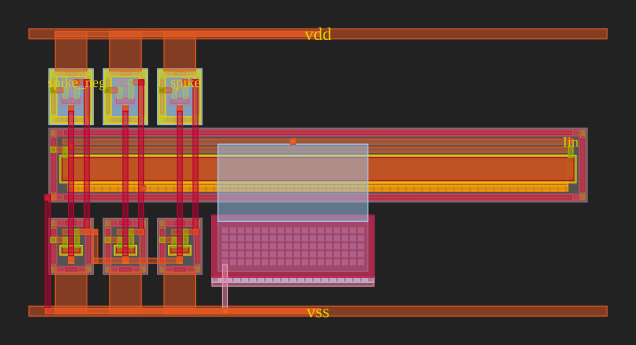

In [13]:

display_component(neurona_comp, scale = 1,path=".")

2026-08-25 04:23:22.669 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


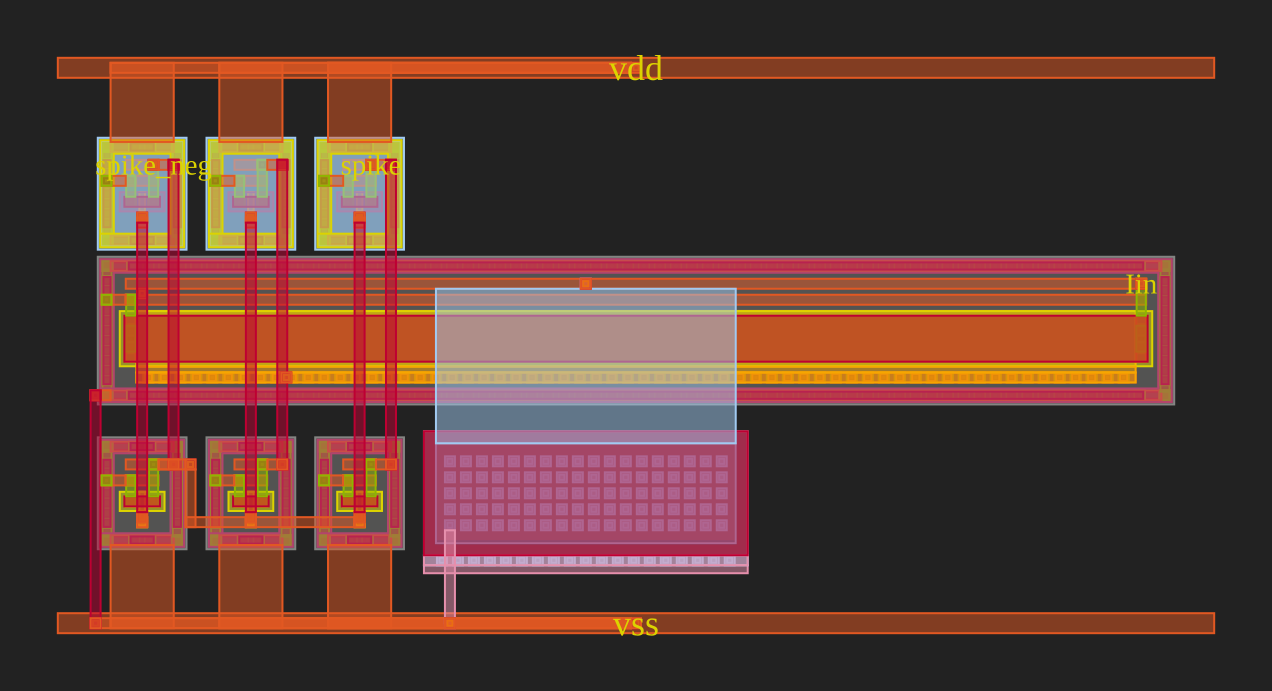

2026-08-25 04:23:22.808 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmprqw5zu5q/neurona_lvs.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmprqw5zu5q/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [14]:
view_and_check_lvs()

In [15]:
neurona_comp.pprint_ports()

┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name      ┃ width ┃ center          ┃ orientation ┃ layer   ┃ port_type  ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━┩
│ vdd       │ 1.0   │ [26.93, 24.09]  │ 180         │ [42, 0] │ electrical │
│ vss       │ 1.0   │ [26.93, -3.7]   │ 180         │ [42, 0] │ electrical │
│ spike     │ 1.0   │ [13.67, 19.235] │ 180         │ [42, 0] │ electrical │
│ spike_neg │ 1.0   │ [2.79, 19.235]  │ 180         │ [42, 0] │ electrical │
│ Iin       │ 1.0   │ [52.21, 13.285] │ 180         │ [42, 0] │ electrical │
└───────────┴───────┴─────────────────┴─────────────┴─────────┴────────────┘

In [16]:
import os
from pathlib import Path
import tempfile
import subprocess

# Configuración de Magic
magicrc_file = Path(os.environ['PDKPATH']) / "libs.tech" / "magic" / f"{os.environ['PDK']}.magicrc"

# Nombre del diseño
design_name = neurona_comp.name

# Ruta donde guardas tus archivos
path_to_dir = "/foss/designs/libs/snn_analog/lif/"

# Archivos de salida
pex_path = path_to_dir + f"{design_name}.spice"
gds_path = path_to_dir + f"{design_name}.gds"

# Exportar GDS
neurona_comp.write_gds(str(gds_path))

#Script de Magic para extracción
magic_script_content = f"""
drc off
gds flatglob *\\$\\$*
gds read {gds_path}

flatten {design_name}
load {design_name}
select top cell
extract do local
extract all
ext2sim labels on
ext2sim
extresist tolerance 10
extresist
ext2spice lvs
ext2spice cthresh 0
ext2spice extresist on
ext2spice -o {pex_path}
exit
"""


# Guardar script temporal
with tempfile.NamedTemporaryFile(mode='w', delete=False) as magic_script_file:
    magic_script_file.write(magic_script_content)
    magic_script_path = magic_script_file.name

# Ejecutar Magic en modo batch
magic_cmd = f"bash -c 'magic -rcfile {magicrc_file} -noconsole -dnull < {magic_script_path}'"
magic_subproc = subprocess.run(
    magic_cmd,
    shell=True,
    check=True,
    capture_output=True
)

# Capturar salida
magic_subproc_code = magic_subproc.returncode
magic_subproc_out = magic_subproc.stdout.decode('utf-8')
print(magic_subproc_out)


2026-08-25 04:23:23.242 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/lif/neurona_lvs.gds'


KeyboardInterrupt: 

In [17]:
import glob
extensions = [
            "els"
            "*.gds",
            "*.ext",
            "*.res.ext",
            "*.lvs.rpt",
            "*_lvs.rpt",
            "*.nodes",
            "*.sim",
            "*.pex.spice",
            "*_pex.spice"
            ]
files_to_delete = []
for ext in extensions:
    files_to_delete.extend(glob.glob(ext))
    
# Delete the files
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f"Deleted: {file_path}")
    except OSError as e:
        print(f"Error deleting {file_path}: {e}")

Deleted: c_route_374a5d00.ext
Deleted: m4.ext
Deleted: L_route_0005fe97.ext
Deleted: m5.ext
Deleted: c_route_73e520aa.ext
Deleted: m7.ext
Deleted: compass_e9c8146d.ext
Deleted: m2.ext
Deleted: c_route_901acad1.ext
Deleted: straight_route_cc6cc387.ext
Deleted: m3.ext
Deleted: straight_route_0d876e8f.ext
Deleted: m1.ext
Deleted: straight_route_f8334bf2.ext
Deleted: straight_route_81ec29d8.ext
Deleted: via_stack_a2e89513$1.ext
Deleted: via_stack_a2e89513$2.ext
Deleted: straight_route_646b9a08.ext
Deleted: via_stack_a2e89513$3.ext
Deleted: straight_route_9f72f82a.ext
Deleted: L_route_fe8feba1.ext
Deleted: via_stack_a2e89513$7.ext
Deleted: via_stack_a2e89513$10.ext
Deleted: straight_route_91ff9046.ext
Deleted: via_stack_a2e89513$6.ext
Deleted: straight_route_801f84af.ext
Deleted: neurona_lvs.res.ext
Deleted: L_route_bff32325.ext
Deleted: L_route_c249da89.ext
Deleted: via_stack_a2e89513$4.ext
Deleted: compass_e9c8146d$1.ext
Deleted: via_stack_a2e89513$5.ext
Deleted: via_stack_a2e89513.ext
De

In [18]:
import os
from pathlib import Path

# Ruta donde guardas tus archivos de la neurona
path_to_dir = "/foss/designs/libs/snn_analog/lif/"

# Ejecutar LVS con Netgen usando el PDK gf180
gf180.lvs_netgen(
    layout=neurona_comp,   # tu layout exportado
    design_name=neurona_comp.name,   # nombre del diseño
    pdk_root=Path(os.environ['PDKPATH']),   # raíz del PDK
    lvs_setup_tcl_file=Path(os.environ['PDKPATH']) / "libs.tech" / "netgen" / f"{os.environ['PDK']}_setup.tcl",
    
    # Netlist de referencia (esquemático ideal)
    lvs_schematic_ref_file=Path(path_to_dir + "neurona_lvs.spice"),
    
    # Netlist extraído del layout (PEX/LVS)
    netlist=Path(path_to_dir + "neurona_sch.spice"),
    
    # Carpeta donde se guarda el reporte .lvs.rpt
    output_file_path=Path(path_to_dir)
)


2026-08-25 04:24:19.518 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpzchho3qe/neurona_lvs.gds'


using user specified pdk_root, will search for required files in the specified directory

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.575-2-g7b70722
Library written using

{'magic_subproc_code': 0,
 'netgen_subproc_code': 0,
 'result_str': 'LVS run succeeded\nErrors found in LVS report: /tmp/tmpzchho3qe/neurona_lvs_lvs.rpt'}

In [ ]:
from pathlib import Path
import os
import subprocess

pdk_name = os.environ.get("PDK", "gf180mcuD")
pdk_root = Path(os.environ.get("PDK_ROOT", ""))
pdk_path_env = Path(os.environ.get("PDKPATH", ""))

# Resolve the correct magicrc path even if PDKPATH is stale or duplicated.
candidate_pdkpaths = [
    pdk_path_env,
    pdk_root / pdk_name,
    pdk_root,
]
magicrc_file = None
for candidate in candidate_pdkpaths:
    if not str(candidate):
        continue
    rc = candidate / "libs.tech" / "magic" / f"{pdk_name}.magicrc"
    if rc.exists():
        magicrc_file = rc
        break

if magicrc_file is None:
    raise FileNotFoundError(
        "No se encontro el magicrc. Revisar PDK_ROOT/PDK/PDKPATH. "
        f"Busque en: {[str(c) for c in candidate_pdkpaths if str(c)]}"
    )

# --- Cambio clave: usar path_to_dir en vez de Path.cwd()/"exports" ---
path_to_dir = "/foss/designs/libs/snn_analog/lif/"
output_dir = Path(path_to_dir)
output_dir.mkdir(parents=True, exist_ok=True)

design_name = neurona_comp.name
gds_path = output_dir / f"{design_name}.gds"
lef_path = output_dir / f"{design_name}.lef"

neurona_comp.write_gds(str(gds_path))

magic_script = f"""
drc off
gds flatglob *\\$\\$*
gds read {gds_path}
load {design_name}
lef write {lef_path}
quit -noprompt
"""

result = subprocess.run(
    ["magic", "-rcfile", str(magicrc_file), "-noconsole", "-dnull"],
    input=magic_script,
    text=True,
    capture_output=True,
    check=True,
)

print(f"CWD kernel: {Path.cwd()}")
print(f"LEF generado: {lef_path}")
print(f"LEF existe: {lef_path.exists()}")
if lef_path.exists():
    print("\nCabecera LEF:")
    with open(lef_path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(15):
            line = f.readline()
            if not line:
                break
            print(line.rstrip())
else:
    print("\n--- STDOUT COMPLETO DE MAGIC (para depurar) ---")
    print(result.stdout)
    print("\n--- STDERR COMPLETO DE MAGIC ---")
    print(result.stderr)